# Universidad del Valle de Guatemala
## Abner Iván García Alegría - 21285
## Ludwing Cano - Cifrado de Información
### Laboratorio 3 - Cifrados Simetricos

## Parte 1: Rompiendo ECB en Imágenes

In [20]:
import numpy as np
from PIL import Image
from Crypto.Cipher import AES
from Crypto.Random import get_random_bytes
import matplotlib.pyplot as plt

In [ ]:
def cargar_imagen(nombre_archivo): # Función para cargar una imagen
    """Carga una imagen (PPM o PNG) y la convierte en un array numpy en escala de grises."""
    img = Image.open(nombre_archivo).convert('L') # Convertir a escala de grises
    return np.array(img) # Convertir a un array numpy

In [ ]:
def guardar_imagen(imagen, nombre_archivo): # Función para guardar una imagen
    """Guarda un array numpy como una imagen PNG en escala de grises."""
    img = Image.fromarray(imagen) # Convertir a imagen
    img.save(nombre_archivo) # Guardar imagen

## Cifrado AES con ECB

In [ ]:
def cifrar_aes_ecb(imagen, clave): # Función para cifrar una imagen con AES en modo ECB
    """Cifra una imagen con AES en modo ECB."""
    cipher = AES.new(clave, AES.MODE_ECB) # Crear cifrador AES en modo ECB con la clave dada
    alto, ancho = imagen.shape # Obtener dimensiones de la imagen
    imagen_plana = imagen.flatten().tobytes() # Convertir imagen a bytes
    # Rellenar con bytes para que la longitud sea un múltiplo de 16
    padding = 16 - len(imagen_plana) % 16 # Calcular número de bytes de relleno
    imagen_plana += bytes([padding] * padding) # Rellenar con el número de bytes de relleno
    imagen_cifrada = cipher.encrypt(imagen_plana) # Cifrar imagen con AES en modo ECB
    # Convertir a array numpy y redimensionar
    imagen_cifrada_np = np.frombuffer(imagen_cifrada, dtype=np.uint8) # Convertir a array numpy 
    imagen_cifrada_np = imagen_cifrada_np[:ancho*alto].reshape(alto, ancho) # Redimensionar a imagen original
    return imagen_cifrada_np # Devolver imagen cifrada

## Cifrado con AES con CBC

In [ ]:
def cifrar_aes_cbc(imagen, clave, iv): # Función para cifrar una imagen con AES en modo CBC
    """Cifra una imagen con AES en modo CBC."""
    cipher = AES.new(clave, AES.MODE_CBC, iv) # Crear cifrador AES en modo CBC con la clave y el vector de inicialización dados
    alto, ancho = imagen.shape # Obtener dimensiones de la imagen
    imagen_plana = imagen.flatten().tobytes() # Convertir imagen a bytes
    # Rellenar con bytes para que la longitud sea un múltiplo de 16
    padding = 16 - len(imagen_plana) % 16 # Calcular número de bytes de relleno 
    imagen_plana += bytes([padding] * padding) # Rellenar con el número de bytes de relleno
    imagen_cifrada = cipher.encrypt(imagen_plana) # Cifrar imagen con AES en modo CBC
    # Convertir a array numpy y redimensionar
    imagen_cifrada_np = np.frombuffer(imagen_cifrada, dtype=np.uint8) # Convertir a array numpy
    imagen_cifrada_np = imagen_cifrada_np[:ancho*alto].reshape(alto, ancho) # Redimensionar a imagen original
    return imagen_cifrada_np # Devolver imagen cifrada

### Ejemplo con una mi imagen

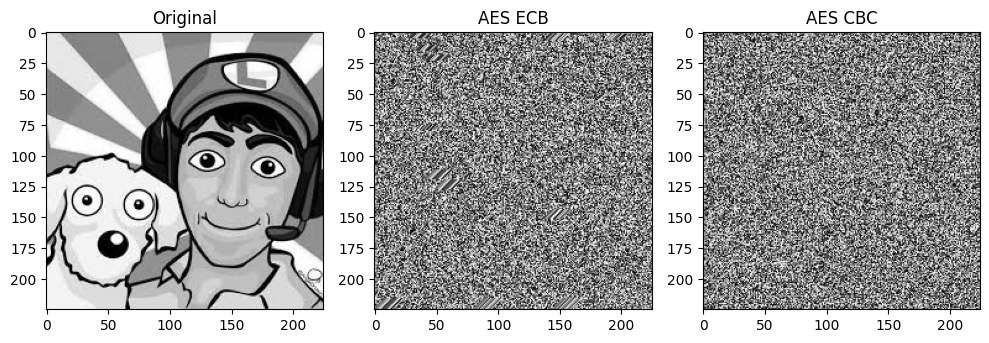

In [ ]:
# Cargar la imagen (puede ser PPM o PNG)
nombre_archivo = input("Ingrese el nombre del archivo de imagen (con extensión): ")  #Permite ingresar el nombre del archivo
imagen_original = cargar_imagen(nombre_archivo)

# Clave AES y vector de inicialización (IV)
clave = get_random_bytes(16)  # 128 bits
iv = get_random_bytes(16)     # 128 bits

# Cifrar con ECB
imagen_ecb_cifrada = cifrar_aes_ecb(imagen_original, clave) # Cifrar la imagen con AES en modo ECB
guardar_imagen(imagen_ecb_cifrada, f'{nombre_archivo.split(".")[0]}_ecb.png') # Guardar la imagen cifrada

# Cifrar con CBC
imagen_cbc_cifrada = cifrar_aes_cbc(imagen_original, clave, iv) # Cifrar la imagen con AES en modo CBC
guardar_imagen(imagen_cbc_cifrada, f'{nombre_archivo.split(".")[0]}_cbc.png') # Guardar la imagen cifrada

# Mostrar las imágenes
plt.figure(figsize=(10, 5))

plt.subplot(1, 3, 1)
plt.imshow(imagen_original, cmap='gray')
plt.title('Original')

plt.subplot(1, 3, 2)
plt.imshow(imagen_ecb_cifrada, cmap='gray')
plt.title('AES ECB')

plt.subplot(1, 3, 3)
plt.imshow(imagen_cbc_cifrada, cmap='gray')
plt.title('AES CBC')

plt.tight_layout()
plt.show()

### Imagen de prueba con tux
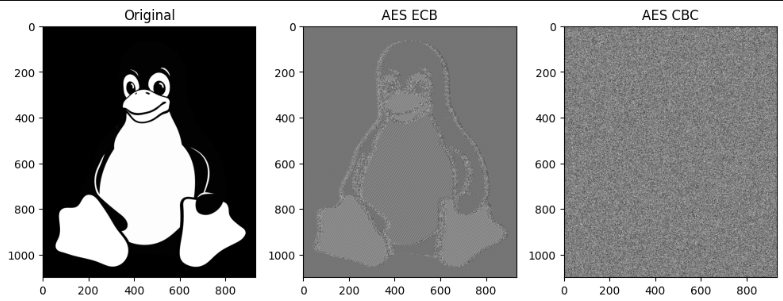

# Preguntas para reflexión